<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week5_kundan_kumar_vennaboina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

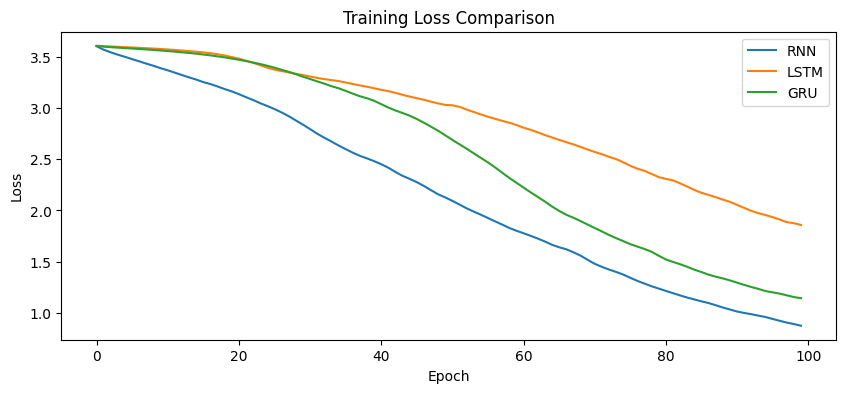

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning models models the the word
GRU : deep learning models can generate meaningful meaningful


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# Student Tasks Implementation

In [10]:
new_corpus = '''
Transformer models have revolutionized natural language processing by enabling parallel processing
 of input sequences, unlike recurrent neural networks. They rely heavily on self-attention mechanisms
  to weigh the importance of different words in a sentence, regardless of their position.
  This architecture allows transformers to capture long-range dependencies effectively,
  leading to state-of-the-art performance in tasks like machine translation and text summarization.
  Despite their computational intensity, their ability to scale with vast datasets makes them a cornerstone of modern AI.
'''
print("New Corpus:")
print(new_corpus)

New Corpus:

Transformer models have revolutionized natural language processing by enabling parallel processing
 of input sequences, unlike recurrent neural networks. They rely heavily on self-attention mechanisms
  to weigh the importance of different words in a sentence, regardless of their position. 
  This architecture allows transformers to capture long-range dependencies effectively, 
  leading to state-of-the-art performance in tasks like machine translation and text summarization. 
  Despite their computational intensity, their ability to scale with vast datasets makes them a cornerstone of modern AI.



In [11]:
# Re-initialize tokenizer and re-process sequences for the new corpus
new_tokenizer = Tokenizer()
new_tokenizer.fit_on_texts([new_corpus])

new_total_words = len(new_tokenizer.word_index) + 1
print("New Vocabulary size:", new_total_words)

new_input_sequences = []
for line in new_corpus.split('\n'):
    new_token_list = new_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(new_token_list)):
        new_n_gram_seq = new_token_list[:i+1]
        new_input_sequences.append(new_n_gram_seq)

new_max_len = max(len(seq) for seq in new_input_sequences)
new_input_sequences = pad_sequences(new_input_sequences, maxlen=new_max_len, padding='pre')

new_X = new_input_sequences[:, :-1]
new_y = new_input_sequences[:, -1]

print("New X shape:", new_X.shape)
print("New y shape:", new_y.shape)

New Vocabulary size: 70
New X shape: (76, 17)
New y shape: (76,)


In [12]:
# New Vanilla RNN Model with updated parameters
new_rnn_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    SimpleRNN(128),
    Dense(new_total_words, activation='softmax')
])

new_rnn_model.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

new_rnn_history = new_rnn_model.fit(new_X, new_y, epochs=200, verbose=0)
print("New Vanilla RNN training completed")

New Vanilla RNN training completed


In [13]:
# New LSTM Model with updated parameters
new_lstm_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    LSTM(128),
    Dense(new_total_words, activation='softmax')
])

new_lstm_model.compile(loss='sparse_categorical_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])

new_lstm_history = new_lstm_model.fit(new_X, new_y, epochs=200, verbose=0)
print("New LSTM training completed")

New LSTM training completed


In [14]:
# New GRU Model with updated parameters
new_gru_model = Sequential([
    Embedding(new_total_words, 64, input_length=new_max_len-1),
    GRU(128),
    Dense(new_total_words, activation='softmax')
])

new_gru_model.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

new_gru_history = new_gru_model.fit(new_X, new_y, epochs=200, verbose=0)
print("New GRU training completed")

New GRU training completed


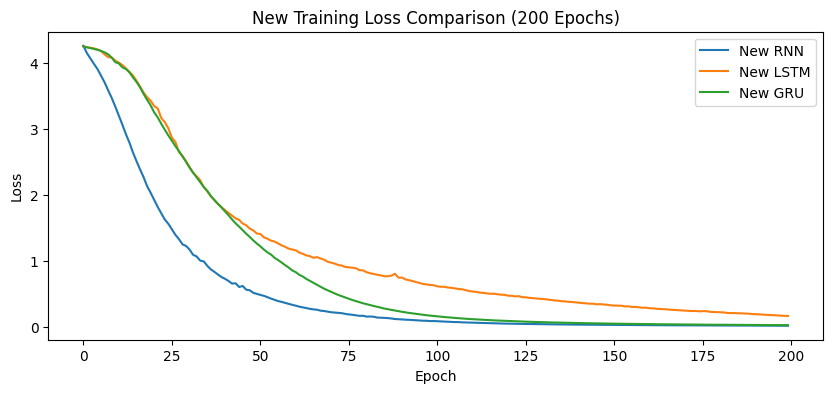

In [15]:
# Plotting training loss for new models
plt.figure(figsize=(10,4))
plt.plot(new_rnn_history.history['loss'], label='New RNN')
plt.plot(new_lstm_history.history['loss'], label='New LSTM')
plt.plot(new_gru_history.history['loss'], label='New GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("New Training Loss Comparison (200 Epochs)")
plt.legend()
plt.show()

In [16]:
# New text generation function using the new tokenizer and max_len
def generate_text_new(model, seed_text, next_words=10):
    for _ in range(next_words):
        new_token_list = new_tokenizer.texts_to_sequences([seed_text])[0]
        new_token_list = pad_sequences([new_token_list], maxlen=new_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(new_token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in new_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

print("New RNN :", generate_text_new(new_rnn_model, "deep learning", 10))
print("New LSTM:", generate_text_new(new_lstm_model, "deep learning", 10))
print("New GRU :", generate_text_new(new_gru_model, "deep learning", 10))

New RNN : deep learning to weigh the importance of different words in a sentence
New LSTM: deep learning their their computational intensity their ability to scale with vast
New GRU : deep learning models have revolutionized natural language processing by enabling parallel processing


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**